In [1]:
import os
import pandas as pd
from pathlib import Path
import re
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
# import librosa
import numpy as np
import matplotlib.pyplot as plt
# from transformers import Wav2Vec2Model, Wav2Vec2Processor
import IPython.display as ipd
import soundfile as sf
from tqdm import tqdm

import subprocess

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.svm import SVC

from scipy.stats import ttest_rel, ttest_1samp, ttest_ind
from scipy import stats

torch.manual_seed(42)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
interview_task_path = "Androids-Corpus/Androids-Corpus/Interview-Task/audio"
interview_data = []

for condition in os.listdir(interview_task_path):
    if condition == ".DS_Store":
        continue
    for clip in os.listdir(interview_task_path + "/" + condition):
        stem = clip.replace(".wav", "")
        uid, mid, t = stem.split("_");
        X = mid[0]
        G = mid[1]
        mm = int(mid[2:])
        interview_data.append({
            "speaker_id": f"{uid}_{X}",
            "condition": X,
            "gender": G,
            "age": mm,
            "education_level": t,
            "path": f"{interview_task_path}/{condition}/{clip}"
        })

interview_df = pd.DataFrame(interview_data)
print(interview_df.head())
print(interview_df[interview_df["condition"] == "P"]["path"].iloc[0])
print(interview_df.shape)

  speaker_id condition gender  age education_level  \
0       01_C         C      F   56               1   
1       02_C         C      M   57               2   
2       03_C         C      F   30               3   
3       04_C         C      F   57               3   
4       05_C         C      F   41               3   

                                                path  
0  Androids-Corpus/Androids-Corpus/Interview-Task...  
1  Androids-Corpus/Androids-Corpus/Interview-Task...  
2  Androids-Corpus/Androids-Corpus/Interview-Task...  
3  Androids-Corpus/Androids-Corpus/Interview-Task...  
4  Androids-Corpus/Androids-Corpus/Interview-Task...  
Androids-Corpus/Androids-Corpus/Interview-Task/audio/PT/01_PM58_2.wav
(116, 6)


In [4]:
interview_df["gender"].value_counts()
interview_df["condition"].value_counts()
interview_df["path"][0]

'Androids-Corpus/Androids-Corpus/Interview-Task/audio/HC/01_CF56_1.wav'

In [5]:
label_of = {sid: 1 if condition == "P" else 0 for sid, condition in zip(interview_df.speaker_id, interview_df.condition)}
gender_of = dict(zip(interview_df.speaker_id, interview_df.gender))
len(label_of.keys())

116

In [6]:
meta = []
for _, row in interview_df.iterrows():

    info = sf.info(row["path"])
    meta.append({
        "speaker_id":    row["speaker_id"],
        "samplerate": info.samplerate,
        "channels":   info.channels,
        "duration":   info.duration,
    })

meta_df = pd.DataFrame(meta)
meta_df.head(5)

,speaker_id,samplerate,channels,duration
0,01_C,44100,1,243.789297
1,02_C,44100,1,255.709297
2,03_C,44100,1,249.909297
3,04_C,44100,1,261.399297
4,05_C,44100,1,291.149297


In [7]:
meta_df["condition"] = meta_df["speaker_id"].map(
    dict(zip(interview_df["speaker_id"], interview_df["condition"]))
)
meta_df["gender"] = meta_df["speaker_id"].map(gender_of)

print("Overall duration (seconds):")
print(meta_df["duration"].describe())

print("\nBy condition (P = depressed, C = control):")
print(meta_df.groupby("condition")["duration"].agg(["mean", "std", "count"]))

print("\nSamplerate check (should be constant if corpus is consistent):")
print(meta_df["samplerate"].value_counts())

p_durations = meta_df[meta_df["condition"] == "P"]["duration"]
c_durations = meta_df[meta_df["condition"] == "C"]["duration"]

t_stat, p_val = ttest_ind(p_durations, c_durations)
print(f"t-test: t={t_stat:.2f}, p={p_val:.6f}")

Overall duration (seconds):
count    116.000000
mean     229.843124
std       86.593584
min       70.649297
25%      159.514297
50%      240.779297
75%      272.461797
max      579.372698
Name: duration, dtype: float64

By condition (P = depressed, C = control):
                 mean        std  count
condition                              
C          268.022374  45.293864     52
P          198.822483  99.227922     64

Samplerate check (should be constant if corpus is consistent):
samplerate
44100    116
Name: count, dtype: int64
t-test: t=-4.65, p=0.000009


In [8]:
SMILE = r"C:\Desertation\opensmile-3.0.2-windows-x86_64\opensmile-3.0.2-windows-x86_64\bin\SMILExtract.exe"

r = subprocess.run([SMILE, "-h"], capture_output=True, text=True)
print(r.stdout[:300])
print("STDERR:", r.stderr[:300])


STDERR:  
   openSMILE version 3.0.1 (Rev. unknown)
   Build date: 2023-10-19T14:13:37Z
   Build branch: 'unknown'
   (c) 2022 by audEERING GmbH
   All rights reserved. See the file COPYING for license terms.


In [9]:
CONF = r"C:\Desertation\Opensmile_dd.conf"

def extract(wav_path, out_csv):
    r = subprocess.run(
        [SMILE, "-C", CONF, "-I", str(wav_path), "-O", str(out_csv)],
        capture_output=True, text=True
    )
    if r.returncode != 0:
        raise RuntimeError(f"{wav_path}\n{r.stderr[-400:]}")
    return pd.read_csv(out_csv)

npz_path = "androids_is09_02.npz"

if not os.path.exists(npz_path):
    features = {}
    for _, row in interview_df.iterrows():
        sid = row["speaker_id"]
        out_csv = f"features/{sid}.csv"
        df = extract(row["path"], out_csv)
        features[sid] = df.values.astype(np.float32)

    np.savez_compressed(npz_path, **features)
    print("Feature extraction complete")
else:
    print("Feature extraction already completed")

Feature extraction already completed


In [10]:
# import soundfile as sf
# import pandas as pd

# path = "Androids-Corpus/Androids-Corpus/Interview-Task/audio/HC/01_CF56_1.wav"
# info = sf.info(path)
# duration = info.frames / info.samplerate
# print("Duration:", duration, "seconds")

# out_csv = "test_01.csv"
# extract(path, out_csv=out_csv)

# df = pd.read_csv(out_csv, sep=",")
# print("Rows (frames):", len(df))
# print("Expected frames at 33ms hop:", duration / 0.033)

In [11]:
data = np.load(npz_path)
features = {k: data[k] for k in data.files}


In [12]:
fold_list = pd.read_csv("Androids-Corpus/Androids-corpus/fold-lists.csv", header=None, skiprows=2)
print(fold_list.head(10))

interview_folds = {}
for i, col in enumerate(range(7, 12), start=1):
    speakers = fold_list[col].dropna().str.strip("'").tolist()
    interview_folds[i] = speakers

            0            1            2            3            4   5   6   \
0  '01_CF56_1'  '05_CF41_3'  '06_CF44_2'  '07_CF50_2'  '03_CF30_3' NaN NaN   
1  '02_CM57_2'  '11_CF44_2'  '15_CF53_3'  '10_CF51_2'  '04_CF57_3' NaN NaN   
2  '09_CF56_3'  '32_CF22_3'  '20_CM51_3'  '12_CF36_1'  '08_CF42_2' NaN NaN   
3  '21_CF58_3'  '46_CF39_3'  '23_CF55_3'  '14_CF49_3'  '13_CF45_2' NaN NaN   
4  '22_CF50_3'  '47_CF61_2'  '26_CM31_3'  '16_CF33_4'  '17_CF55_3' NaN NaN   
5  '25_CF59_3'  '07_PM39_4'  '27_CF63_4'  '28_CF34_3'  '18_CM64_3' NaN NaN   
6  '33_CF46_3'  '13_PF58_2'  '30_CF62_3'  '29_CF34_3'  '19_CF62_4' NaN NaN   
7  '41_CM71_2'  '14_PF35_3'  '31_CF55_2'  '36_CF59_2'  '24_CM63_3' NaN NaN   
8  '55_CM29_3'  '15_PM63_4'  '37_CF69_1'  '42_CF53_4'  '38_CM27_3' NaN NaN   
9  '56_CM23_3'  '21_PM33_3'  '39_CM27_3'  '48_CF34_3'  '40_CF59_1' NaN NaN   

            7            8            9            10           11  
0  '01_CF56_1'  '12_CF36_1'  '03_CF30_3'  '05_CF41_3'  '06_CF44_2'  
1  

In [13]:
fold_summary = {}

for fold in interview_folds:
    if fold not in fold_summary:
        fold_summary[fold] = {'P': 0, 'C': 0}
    for speaker in interview_folds[fold]:
        speaker_type = speaker.split("_")[1][0]
        fold_summary[fold][speaker_type] += 1

print(f"Class ballance summary in each fold\n{fold_summary}")

Class ballance summary in each fold
{1: {'P': 12, 'C': 12}, 2: {'P': 13, 'C': 10}, 3: {'P': 10, 'C': 13}, 4: {'P': 18, 'C': 5}, 5: {'P': 11, 'C': 12}}


In [14]:
train_speakers = [s[:4] for f, sp in interview_folds.items() if f != 1 for s in sp]
X_train = np.vstack([data[s] for s in train_speakers])
print(X_train.shape)
total = sum(len(data[s]) for s in data)
print(total)
print(X_train.dtype, X_train.nbytes / 1e9, "GB")

(646710, 32)
808154
float32 0.08277888 GB


In [15]:
class AndroidsSegmentDataset(Dataset):
    def __init__(self, data_dict, speaker_ids, labels_dict, segment_length=128):
        self.segments = []
        self.labels = []
        self.speaker_ids = []
        self.segment_length = segment_length

        for sid in speaker_ids:
            if sid not in data_dict:
                continue

            X = data_dict[sid]
            y = labels_dict[sid]

            n_segments = len(X) // segment_length

            if n_segments == 0:
                continue

            X_truncated = X[:n_segments * segment_length]
            X_reshaped = X_truncated.reshape(n_segments, segment_length, -1)


            for seg in X_reshaped:
                self.segments.append(seg)
                self.labels.append(y)
                self.speaker_ids.append(sid)

        self.segments = torch.tensor(np.array(self.segments), dtype=torch.float32)
        self.labels = torch.tensor(np.array(self.labels), dtype=torch.float32)

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        return self.segments[idx], self.labels[idx], self.speaker_ids[idx]

In [16]:
k = 1
train_speakers = [s[:4] for f, sp in interview_folds.items() if f != k for s in sp]
test_speakers = [s[:4] for s in interview_folds[k]] 

X_train = np.vstack([data[s] for s in train_speakers if s in data])
scaler = StandardScaler()
scaler.fit(X_train)

scaled_data = {}

for sid in data.files:
    scaled_data[sid] = scaler.transform(data[sid])

train_dataset = AndroidsSegmentDataset(
    data_dict=scaled_data,
    labels_dict=label_of,
    speaker_ids=train_speakers,
    segment_length=128
)

test_dataset = AndroidsSegmentDataset(
    data_dict=scaled_data,
    labels_dict=label_of,
    speaker_ids=test_speakers,
    segment_length=128
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=True)

print(f"Train Segments: {len(train_dataset)} | Train Batches: {len(train_loader)}")
print(f"Test Segments:  {len(test_dataset)}  | Test Batches:  {len(test_loader)}")

Train Segments: 5006 | Train Batches: 10
Test Segments:  1248  | Test Batches:  3


In [17]:
class StackedRNN(nn.Module):
    def __init__(self, input_size=32, hidden_size=70, num_layers=2):
        super(StackedRNN, self).__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity='tanh',
            batch_first=True,
            dropout=0.3 # overfitting issue
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)

        last_step_out = rnn_out[:, -1, :]

        logits = self.fc(last_step_out)

        return logits

In [18]:
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0

    for segments, labels, _ in train_loader:
        segments = segments.to(device) # shape: (batch_size, 128, 32)
        labels = labels.to(device).unsqueeze(1) # shape: (batch_size, 1)

        optimizer.zero_grad()

        outputs = model(segments)
        loss = criterion(outputs, labels)

        loss.backward()

        # gradiant clipping to address sharp spikes in fold 4
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()

        running_loss += loss.item() * segments.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

In [19]:
def evaluate_loss(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for segments, labels, _ in data_loader:
            segments = segments.to(device) # shape: (batch_size, 128, 32)
            labels = labels.to(device).unsqueeze(1) # shape: (batch_size, 1)

            outputs = model(segments)
            loss = criterion(outputs, labels) 

            running_loss += loss.item() * segments.size(0)

    epoch_loss = running_loss / len(data_loader.dataset)
    return epoch_loss


In [20]:
def evaluate_speakers(model, data_loader):
    model.eval()

    speaker_probs = {}
    speaker_labels = {}

    with torch.no_grad():
        for segments, labels, speaker_ids in data_loader:
            segments = segments.to(device)


            logits = model(segments)
            probs = torch.sigmoid(logits).cpu().numpy()
            labels = labels.cpu().numpy()

            for i, sid in enumerate(speaker_ids):
                if sid not in speaker_probs:
                    speaker_probs[sid] = []
                    speaker_labels[sid] = int(labels[i])
                speaker_probs[sid].append(probs[i])


    y_true, y_pred_smv, y_pred_wa, sids = [], [], [], []

    for sid in speaker_probs:
        probs = np.array(speaker_probs[sid])
        y_true.append(speaker_labels[sid])
        sids.append(sid)

        # segment majority vote (smv)
        segment_classes = (probs > 0.5).astype(int)
        y_pred_smv.append(int(np.mean(segment_classes) > 0.5))

        # weighted average (wa)
        y_pred_wa.append(int(np.mean(probs) > 0.5))

    return y_true, y_pred_smv, y_pred_wa, sids

In [21]:
def compute_metrics(y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)
        # zero_division=0 avoids warnings/crashes on folds with few positive predictions
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='binary', zero_division=0
        )
        return {"acc": acc, "precision": prec, "recall": rec, "f1": f1}

def summarize(metrics_list, name, folds=5):
    df = pd.DataFrame(metrics_list)
    print(f"\n{name} — mean ± std across {folds} folds")
    for col in ["acc", "precision", "recall", "f1"]:
        print(f"  {col.capitalize():10s}: {df[col].mean()*100:.1f} ± {df[col].std()*100:.1f}")
    return df

def gender_split_metrics(pooled_preds, name, pred_col="y_pred_wa"):
    df = pd.DataFrame(pooled_preds)
    df["gender"] = df["sid"].map(gender_of)

    results = {}
    for g in ["F", "M"]:
        sub = df[df["gender"] == g]
        results[g] = compute_metrics(sub["y_true"].tolist(), sub[pred_col].tolist())
    
    metrics_df = pd.DataFrame({
        "Female": [results["F"][col] * 100 for col in ["acc", "precision", "recall", "f1"]],
        "Male": [results["M"][col] * 100 for col in ["acc", "precision", "recall", "f1"]]
    }, index=["Acc", "Precision", "Recall", "F1"]).round(1)
    
    print(f"\n{name} — Gender Split")
    print(metrics_df)
    
    return metrics_df

In [22]:
def summarize_and_split(metrics_list, pooled_preds, name, pred_col="y_pred_wa"):
    # Calculate Overall Mean ± Std across folds
    df_folds = pd.DataFrame(metrics_list)
    overall_stats = [
        f"{df_folds[col].mean()*100:.1f} ± {df_folds[col].std()*100:.1f}" 
        for col in ["acc", "precision", "recall", "f1"]
    ]
    
    # Calculate Gender Split on pooled predictions
    df_preds = pd.DataFrame(pooled_preds)
    df_preds["gender"] = df_preds["sid"].map(gender_of)
    
    results = {}
    for g in ["F", "M"]:
        sub = df_preds[df_preds["gender"] == g]
        results[g] = compute_metrics(sub["y_true"].tolist(), sub[pred_col].tolist())
        
    # Combine into a single DataFrame
    final_df = pd.DataFrame({
        "Overall (Mean ± Std)": overall_stats,
        "Female": [results["F"][col] * 100 for col in ["acc", "precision", "recall", "f1"]],
        "Male": [results["M"][col] * 100 for col in ["acc", "precision", "recall", "f1"]]
    }, index=["Acc", "Precision", "Recall", "F1"])
    
    # Round the numeric columns
    final_df["Female"] = final_df["Female"].round(1)
    final_df["Male"] = final_df["Male"].round(1)
    
    print(f"\n{name} — Performance Summary")
    print(final_df)
    
    return final_df

In [23]:
from sklearn.svm import SVC
folds = 5
svm_fold_metrics = []
svm_pooled_preds = []
for k in range(1, folds + 1):
    test_speakers = [s[:4] for s in interview_folds[k]]
    train_speakers = [s[:4] for f, sp in interview_folds.items() if f != k for s in sp]

    X_train = np.vstack([data[s].mean(axis=0) for s in train_speakers])   # (92, 32)
    Y_train = np.array([label_of[s] for s in train_speakers])             # (92,)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    clf = SVC(kernel="linear").fit(X_train, Y_train)

    X_test = scaler.transform(np.vstack([data[s].mean(axis=0) for s in test_speakers]))
    Y_pred = clf.predict(X_test)
    Y_true = [label_of[s] for s in test_speakers]

    svm_fold_metrics.append(compute_metrics(Y_true, Y_pred))
    for sid, yt, yp in zip(test_speakers, Y_true, Y_pred):
        svm_pooled_preds.append({"sid": sid, "y_true": yt, "y_pred": yp})

summarize_and_split(svm_fold_metrics, svm_pooled_preds, "SVM", pred_col="y_pred")


SVM — Performance Summary
          Overall (Mean ± Std)  Female   Male
Acc                 80.2 ± 4.9    78.6   84.4
Precision          80.9 ± 11.2    82.1   80.8
Recall              82.8 ± 6.3    74.4  100.0
F1                  81.4 ± 6.7    78.0   89.4


,Overall (Mean ± Std),Female,Male
Acc,80.2 ± 4.9,78.6,84.4
Precision,80.9 ± 11.2,82.1,80.8
Recall,82.8 ± 6.3,74.4,100.0
F1,81.4 ± 6.7,78.0,89.4


In [24]:
def run_lr(segment_length, folds=5):
    smv_metrics, wa_metrics = [], []
    pooled_preds = []

    for k in range(1, folds + 1):
        test_speakers = [s[:4] for s in interview_folds[k]]
        train_speakers = [s[:4] for f, sp in interview_folds.items() if f != k for s in sp]

        assert not set(train_speakers) & set(test_speakers)
        assert all(s in data for s in train_speakers + test_speakers)

        X_train = np.vstack([data[s] for s in train_speakers])
        Y_train = np.concatenate([np.full(len(data[s]), label_of[s]) for s in train_speakers])

        scalar = StandardScaler()
        X_train = scalar.fit_transform(X_train)

        clf = LogisticRegression(max_iter=1000).fit(X_train, Y_train)

        Y_true, Y_pred_smv, Y_pred_wa, sids = [], [], [], []
        for sid in test_speakers:
            X_test = scalar.transform(data[sid])

            n_segments = len(X_test) // segment_length
            if n_segments == 0:
                continue

            feature_segments = np.array_split(X_test[:n_segments * segment_length], n_segments)

            seg_labels_smv = []
            seg_probs_wa = []

            for seg in feature_segments:
                probs = clf.predict_proba(seg)[:, 1]

                frame_preds = (probs > 0.5).astype(int)
                seg_labels_smv.append(int(frame_preds.mean() > 0.5))

                seg_probs_wa.append(probs.mean())

            speaker_pred_smv = int(np.mean(seg_labels_smv) > 0.5)
            speaker_pred_wa = int(np.mean(seg_probs_wa) > 0.5)

            Y_pred_smv.append(speaker_pred_smv)
            Y_pred_wa.append(speaker_pred_wa)
            Y_true.append(label_of[sid])
            sids.append(sid)

        smv_metrics.append(compute_metrics(Y_true, Y_pred_smv))
        wa_metrics.append(compute_metrics(Y_true, Y_pred_wa))
        for sid, yt, yp_smv, yp_wa in zip(sids, Y_true, Y_pred_smv, Y_pred_wa):
            pooled_preds.append({"sid": sid, "y_true": yt, "y_pred_smv": yp_smv, "y_pred_wa": yp_wa})

    return smv_metrics, wa_metrics, pooled_preds

In [25]:
def run_rnn(segment_length, folds=5, hidden_size=70, epochs=30, verbose=False):
    smv_metrics = []
    wa_metrics = []
    pooled_preds = []
    loss_curves = {}

    for k in range(1, folds + 1):
        test_speakers = [s[:4] for s in interview_folds[k]]
        train_speakers = [s[:4] for f, sp in interview_folds.items() if f != k for s in sp]

        X_train = np.vstack([data[s] for s in train_speakers if s in data])
        scaler = StandardScaler()
        scaler.fit(X_train)
        scaled_data = {sid: scaler.transform(data[sid]) for sid in data.files}

        train_dataset = AndroidsSegmentDataset(
            data_dict=scaled_data, labels_dict=label_of,
            speaker_ids=train_speakers, segment_length=segment_length
        )
        test_dataset = AndroidsSegmentDataset(
            data_dict=scaled_data, labels_dict=label_of,
            speaker_ids=test_speakers, segment_length=segment_length
        )

        if len(train_dataset) == 0 or len(test_dataset) == 0:
            print(f"  [seg_len={segment_length}, fold={k}] skipped — empty split")
            continue

        train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

        model = StackedRNN(input_size=32, hidden_size=hidden_size, num_layers=2).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

        fold_train_losses, fold_test_losses = [], []
        iterator = tqdm(range(epochs), desc=f"seg_len={segment_length} fold={k}") if verbose else range(epochs)
        for epoch in iterator:
            train_loss = train_epoch(model, train_loader=train_loader, criterion=criterion, optimizer=optimizer)
            test_loss = evaluate_loss(model, data_loader=test_loader, criterion=criterion)
            fold_train_losses.append(train_loss)
            fold_test_losses.append(test_loss)

        loss_curves[k] = {"train": fold_train_losses, "test": fold_test_losses}

        y_true, y_pred_smv, y_pred_wa, sids = evaluate_speakers(model, data_loader=test_loader)
        smv_metrics.append(compute_metrics(y_true, y_pred_smv))
        wa_metrics.append(compute_metrics(y_true, y_pred_wa))

        for sid, yt, yp_smv, yp_wa in zip(sids, y_true, y_pred_smv, y_pred_wa):
            pooled_preds.append({"sid": sid, "y_true": yt, "y_pred_smv": yp_smv, "y_pred_wa": yp_wa})

    return smv_metrics, wa_metrics, loss_curves, pooled_preds

In [ ]:
SEEDS = (0, 1, 2, 3, 4)   # R = 5 repetitions; MUST match the other notebook

def run_rnn_seeds(segment_length, seeds=SEEDS, **kw):
    """Repeat the full 5-fold cross-validation once per random initialisation,
    then average the repetitions *within* each fold.

    The returned lists therefore hold one entry per fold, with variance due to
    random initialisation averaged out and variance due to data sampling
    preserved. Every reported standard deviation and every statistical test in
    this notebook is computed over these five fold-level values.
    """
    metrics = ["acc", "precision", "recall", "f1"]
    per_seed_smv, per_seed_wa = [], []
    all_pooled = []
    loss_curves_seed0 = {}

    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)

        smv_folds, wa_folds, curves, pooled = run_rnn(segment_length, **kw)
        per_seed_smv.append(smv_folds)
        per_seed_wa.append(wa_folds)

        if seed == seeds[0]:
            loss_curves_seed0 = curves   # {fold: {"train": [...], "test": [...]}}

        for p in pooled:
            all_pooled.append({**p, "seed": seed})

    n_folds = len(per_seed_smv[0])
    for r in per_seed_smv + per_seed_wa:
        assert len(r) == n_folds, f"inconsistent fold count across repetitions: {len(r)} vs {n_folds}"

    def average_within_folds(per_seed):
        return [
            {m: float(np.mean([per_seed[r][k][m] for r in range(len(per_seed))])) for m in metrics}
            for k in range(n_folds)
        ]

    return average_within_folds(per_seed_smv), average_within_folds(per_seed_wa), loss_curves_seed0, all_pooled


In [27]:
n_folds_sim = 1000 # sim many trials
p_patient = 64 / (64 + 52)

random_metrics = {'acc': [], 'precision': [], 'recall': [], 'f1': []}


for _ in range(n_folds_sim):
    y_true = np.random.choice([0, 1], size=116, p=[1-p_patient, p_patient])
    y_pred = np.random.choice([0, 1], size=116, p=[1-p_patient, p_patient])
    m = compute_metrics(y_true, y_pred)
    for key in random_metrics:
        random_metrics[key].append(m[key])

random_baseline = {key: np.mean(vals) for key, vals in random_metrics.items()}

print("Random baseline (expected values):")
for key, val in random_baseline.items():
    print(f"  {key:10s}: {val*100:.1f}")

Random baseline (expected values):
  acc       : 50.6
  precision : 55.1
  recall    : 55.4
  f1        : 55.1


In [ ]:
segment_lengths = [32, 64, 128, 256, 512, 1024]

lr_smv_results, lr_wa_results, lr_pooled_results = {}, {}, {}
rnn_smv_results, rnn_wa_results = {}, {}
rnn_loss_curves, rnn_pooled_results = {}, {}

for seg_len in segment_lengths:
    print(f"\nSegment length: {seg_len}")

    # --- static baseline: deterministic, one value per fold ---
    lr_smv, lr_wa, pooled_preds = run_lr(seg_len)
    lr_smv_results[seg_len] = lr_smv
    lr_wa_results[seg_len] = lr_wa
    lr_pooled_results[seg_len] = pooled_preds
    summarize_and_split(lr_smv, pooled_preds, "LR (SMV)", pred_col="y_pred_smv")
    summarize_and_split(lr_wa, pooled_preds, "LR (WA)", pred_col="y_pred_wa")

    # --- temporal model: R repetitions, averaged within each fold ---
    rnn_smv, rnn_wa, curves, pooled_preds = run_rnn_seeds(
        seg_len, hidden_size=70, epochs=30
    )
    rnn_smv_results[seg_len] = rnn_smv      # 5 fold-level entries
    rnn_wa_results[seg_len] = rnn_wa
    rnn_loss_curves[seg_len] = curves       # seed 0 only, {fold: {...}}
    rnn_pooled_results[seg_len] = pooled_preds
    summarize_and_split(rnn_smv, pooled_preds, f"RNN (SMV) - R={len(SEEDS)}", pred_col="y_pred_smv")
    summarize_and_split(rnn_wa, pooled_preds, f"RNN (WA) - R={len(SEEDS)}", pred_col="y_pred_wa")


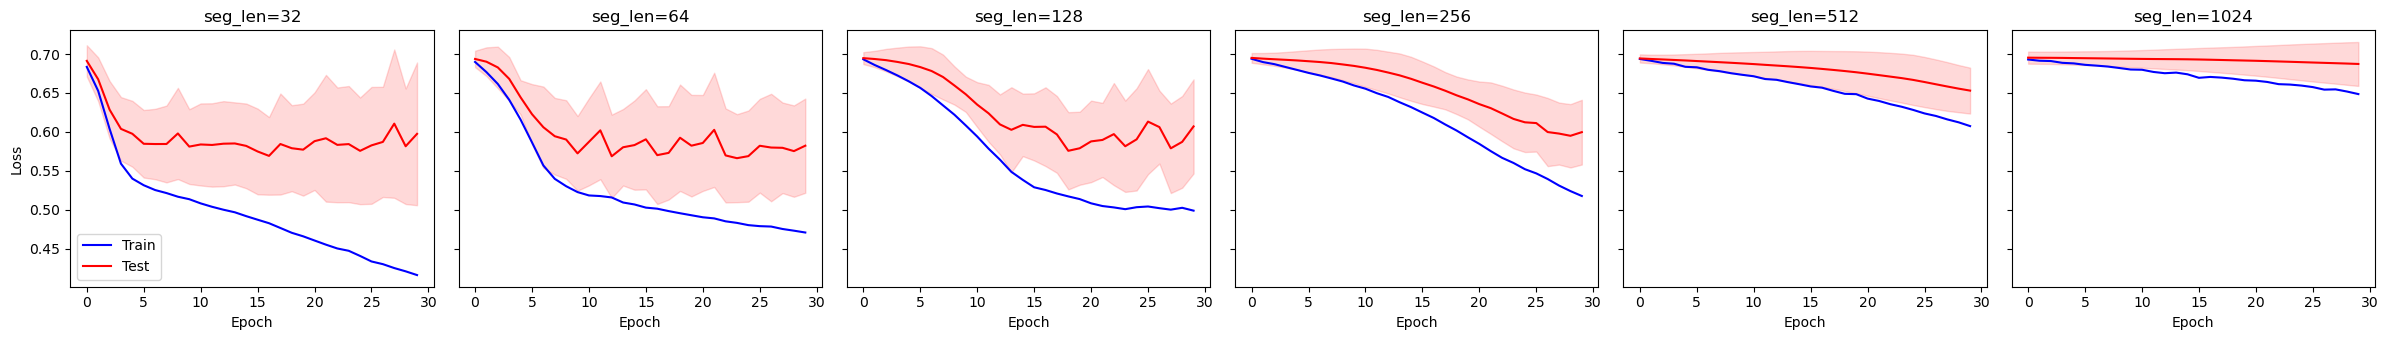

In [29]:
# Loss curves for a single initialisation (seed 0); the pattern was consistent
# across repetitions, so only one is shown.
fig, axes = plt.subplots(1, len(segment_lengths), figsize=(4*len(segment_lengths), 3.5), sharey=True)

for ax, seg_len in zip(axes, segment_lengths):
    curves = rnn_loss_curves[seg_len]
    train_arr = np.array([c["train"] for c in curves.values()])  # (n_folds, epochs)
    test_arr  = np.array([c["test"]  for c in curves.values()])

    ax.plot(train_arr.mean(axis=0), color='blue', label='Train')
    ax.plot(test_arr.mean(axis=0), color='red', label='Test')
    ax.fill_between(range(train_arr.shape[1]),
                     test_arr.mean(axis=0) - test_arr.std(axis=0),
                     test_arr.mean(axis=0) + test_arr.std(axis=0),
                     color='red', alpha=0.15)
    ax.set_title(f"seg_len={seg_len}")
    ax.set_xlabel("Epoch")

axes[0].set_ylabel("Loss")
axes[0].legend()
plt.tight_layout()
plt.show()


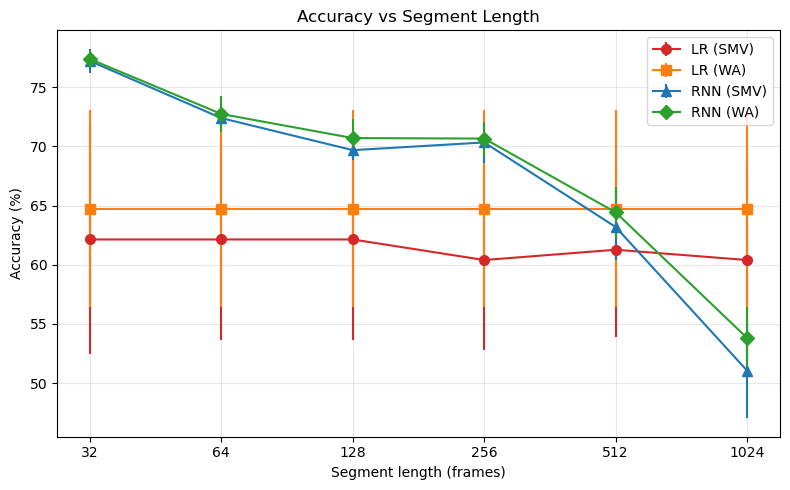

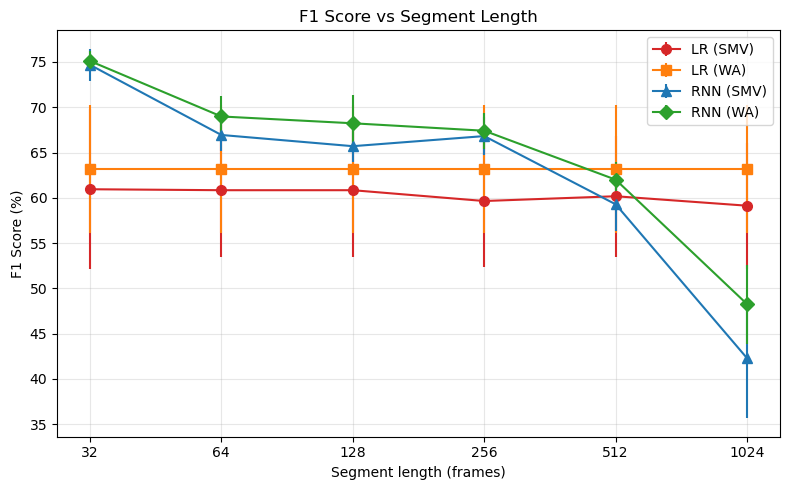

In [30]:
def mean_std(results_dict, key):
    means, stds = [], []
    for seg_len in segment_lengths:
        vals = np.array([m[key] for m in results_dict[seg_len]])
        means.append(vals.mean() * 100)
        stds.append(vals.std() * 100)
    return np.array(means), np.array(stds)

model_series = [
    (lr_smv_results,  "LR (SMV)",  "tab:red",    "o"),
    (lr_wa_results,   "LR (WA)",   "tab:orange", "s"),
    (rnn_smv_results, "RNN (SMV)", "tab:blue",   "^"),
    (rnn_wa_results,  "RNN (WA)",  "tab:green",  "D"),
]

def plot_metric(metric_key, metric_label, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for results, label, color, marker in model_series:
        m, s = mean_std(results, metric_key)
        ax.errorbar(segment_lengths, m, yerr=s, marker=marker, markersize=7,
            label=label, color=color)

    ax.set_xscale("log", base=2)
    ax.set_xticks(segment_lengths)
    ax.set_xticklabels(segment_lengths)
    ax.set_xlabel("Segment length (frames)")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label.split(' (')[0]} vs Segment Length")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_metric("acc", "Accuracy (%)", "accuracy_vs_segment_length.png")
plot_metric("f1", "F1 Score (%)", "f1_vs_segment_length.png")

In [31]:
def build_summary_df(results_dict, pooled_preds, model_name, pred_col="y_pred"):
    rows = []
    for seg_len in segment_lengths:
        row = {"Model": model_name, "Segment Length": seg_len}

        df_preds = pd.DataFrame(pooled_preds[seg_len])
        df_preds["gender"] = df_preds["sid"].map(gender_of)
        
        for metric in ["acc", "precision", "recall", "f1"]:
            vals = [fold[metric] for fold in results_dict[seg_len]]
            row[metric.capitalize()] = f"{np.mean(vals)*100:.1f} ± {np.std(vals, ddof=1)*100:.1f}"
        for g in ["F", "M"]:
            sub = df_preds[df_preds["gender"] == g]
            temp_gender_results = compute_metrics(sub["y_true"].tolist(), sub[pred_col].tolist())
            gender_placeholder = "Male" if g == "M" else "Female"
            row[f"{gender_placeholder.title()} F1"] = round(temp_gender_results["f1"]*100, 1)
        rows.append(row)
    return pd.DataFrame(rows)

svm_row = {"Model": "SVM", "Segment Length": "-"}
svm_df_preds = pd.DataFrame(svm_pooled_preds)
svm_df_preds["gender"] = svm_df_preds["sid"].map(gender_of)
for metric in ["acc", "precision", "recall", "f1"]:
    vals = [fold[metric] for fold in svm_fold_metrics]
    svm_row[metric.capitalize()] = f"{np.mean(vals)*100:.1f} ± {np.std(vals, ddof=1)*100:.1f}"
for g in ["F", "M"]:
    sub = svm_df_preds[svm_df_preds["gender"] == g]
    temp_gender_results = compute_metrics(sub["y_true"].tolist(), sub["y_pred"].tolist())
    gender_placeholder = "Male" if g == "M" else "Female"
    svm_row[f"{gender_placeholder.title()} F1"] = round(temp_gender_results["f1"]*100, 1)
df_svm = pd.DataFrame([svm_row])

df_rnn_smv = build_summary_df(rnn_smv_results, rnn_pooled_results, "RNN (SMV)", pred_col="y_pred_smv")
df_rnn_wa  = build_summary_df(rnn_wa_results,  rnn_pooled_results, "RNN (WA)",  pred_col="y_pred_wa")
df_lr_smv  = build_summary_df(lr_smv_results,  lr_pooled_results,  "LR (SMV)",  pred_col="y_pred_smv")
df_lr_wa   = build_summary_df(lr_wa_results,   lr_pooled_results,  "LR (WA)",   pred_col="y_pred_wa")

final_df = pd.concat([df_svm, df_lr_smv, df_lr_wa, df_rnn_smv, df_rnn_wa])
final_df.set_index(['Model', 'Segment Length'], inplace=True)

display(final_df)

Acc    Precision      Recall          F1  \
Model     Segment Length                                                    
SVM       -               80.2 ± 4.4  80.9 ± 10.0  82.8 ± 5.6  81.4 ± 6.0   
LR (SMV)  32              62.1 ± 9.7  74.1 ± 19.5  54.5 ± 9.1  60.9 ± 8.8   
          64              62.1 ± 8.5  73.4 ± 17.2  54.5 ± 9.1  60.8 ± 7.4   
          128             62.1 ± 8.5  73.4 ± 17.2  54.5 ± 9.1  60.8 ± 7.4   
          256             60.4 ± 7.6  70.8 ± 18.2  54.5 ± 9.1  59.6 ± 7.3   
          512             61.3 ± 7.4  71.9 ± 17.0  54.5 ± 9.1  60.2 ± 6.7   
          1024            60.4 ± 8.1  71.9 ± 18.2  52.9 ± 8.4  59.1 ± 6.9   
LR (WA)   32              64.7 ± 8.3  76.6 ± 16.8  55.6 ± 7.3  63.2 ± 7.1   
          64              64.7 ± 8.3  76.6 ± 16.8  55.6 ± 7.3  63.2 ± 7.1   
          128             64.7 ± 8.3  76.6 ± 16.8  55.6 ± 7.3  63.2 ± 7.1   
          256             64.7 ± 8.3  76.6 ± 16.8  55.6 ± 7.3  63.2 ± 7.1   
          512             64.7 ± 8.3  76.6 ± 16.8  55.6 ± 7.3  63.2 ± 7.1   
          1024            64.7 ± 8.3  76.6 ± 16.8  55.6 ± 7.3  63.2 ± 7.1   
RNN (SMV) 32              77.2 ± 1.0   94.8 ± 4.4  62.6 ± 3.8  74.7 ± 1.8   
          64              72.4 ± 0.9   94.2 ± 2.8  52.8 ± 2.9  66.9 ± 1.7   
          128             69.7 ± 0.8   80.7 ± 1.6  56.7 ± 2.9  65.7 ± 1.7   
          256             70.3 ± 1.8   80.9 ± 3.4  57.9 ± 2.0  66.8 ± 2.1   
          512             63.2 ± 2.8   77.2 ± 3.2  49.4 ± 2.4  59.3 ± 3.0   
          1024            51.0 ± 4.0  59.5 ± 13.3  36.5 ± 6.0  42.3 ± 6.6   
RNN (WA)  32              77.4 ± 0.7   92.5 ± 4.6  64.2 ± 3.1  75.1 ± 1.1   
          64              72.7 ± 1.5   88.1 ± 3.7  57.8 ± 3.9  69.0 ± 2.2   
          128             70.7 ± 1.6   80.0 ± 1.2  60.9 ± 4.9  68.2 ± 3.1   
          256             70.7 ± 1.4   80.5 ± 1.8  58.7 ± 2.4  67.4 ± 2.0   
          512             64.4 ± 2.2   76.4 ± 3.0  53.5 ± 1.6  62.0 ± 1.9   
          1024            53.8 ± 2.6   70.0 ± 2.3  43.3 ± 4.6  48.3 ± 4.4   

                          Female F1  Male F1  
Model     Segment Length                      
SVM       -                    78.0     89.4  
LR (SMV)  32                   48.5     78.3  
          64                   49.2     76.6  
          128                  49.2     76.6  
          256                  47.8     76.6  
          512                  48.5     76.6  
          1024                 46.2     76.6  
LR (WA)   32                   52.3     78.3  
          64                   52.3     78.3  
          128                  52.3     78.3  
          256                  52.3     78.3  
          512                  52.3     78.3  
          1024                 52.3     78.3  
RNN (SMV) 32                   68.5     86.9  
          64                   57.7     85.4  
          128                  58.1     83.9  
          256                  59.1     84.8  
          512                  48.9     74.2  
          1024                 39.6     47.9  
RNN (WA)  32                   69.4     87.4  
          64                   61.5     85.4  
          128                  61.8     83.7  
          256                  59.9     85.2  
          512                  51.9     76.2  
          1024                 46.8     51.8

In [ ]:
def mean_metric(metrics_list, metric="f1"):
    """Collapse a list of fold-level dicts into a single scalar."""
    return float(np.mean([m[metric] for m in metrics_list]))


def paired_stats(metrics_a, metrics_b, metric="f1"):
    """Paired two-tailed t-test between two methods over the five folds.

    Pairing is appropriate because every method is evaluated on the identical
    folds and identical speakers, so fold-to-fold variation is shared and can
    be removed. For the recurrent model, repetitions have already been averaged
    within each fold, so the variance tested here is variation across data
    splits rather than across random initialisations.
    """
    a = np.array([m[metric] for m in metrics_a])
    b = np.array([m[metric] for m in metrics_b])
    diff = a - b
    t_stat, p_val = stats.ttest_rel(a, b)
    return diff.mean() * 100, t_stat, p_val


def vs_random_stats(metrics, random_baseline, metric="f1"):
    """One-sample, one-tailed t-test against the random baseline."""
    a = np.array([m[metric] for m in metrics])
    t_stat, p_val = stats.ttest_1samp(a, random_baseline[metric], alternative='greater')
    return a.mean() * 100 - random_baseline[metric] * 100, t_stat, p_val


In [ ]:
alpha = 0.05

# Every comparison below is computed on fold-level values. For the recurrent
# model the repetitions were averaged within each fold during training, so all
# models are on the same footing and the variance being tested is variation
# across data splits.

# Question 1: is the temporal classifier (RNN) better than the static
# classifier (LR), matched by aggregation strategy?
n_temporal_vs_static = 2   # RNN(SMV) vs LR(SMV), RNN(WA) vs LR(WA)
temporal_vs_static_alpha = alpha / n_temporal_vs_static

# Question 2: does each model/aggregation combination beat chance?
n_above_chance = 4  # RNN(SMV), RNN(WA), LR(SMV), LR(WA) vs Random
above_chance_alpha = alpha / n_above_chance

segment_lengths_all = sorted(set(segment_lengths))
rows = []

for seg_len in segment_lengths_all:
    if seg_len not in rnn_wa_results or seg_len not in lr_smv_results:
        continue

    temporal_vs_static = [
        ("RNN (SMV) vs LR (SMV)", rnn_smv_results[seg_len], lr_smv_results[seg_len]),
        ("RNN (WA) vs LR (WA)",   rnn_wa_results[seg_len],  lr_wa_results[seg_len]),
    ]
    for label, m_a, m_b in temporal_vs_static:
        mean_diff, t_stat, p_raw = paired_stats(m_a, m_b, metric="f1")
        rows.append({
            "segment_length": seg_len,
            "question": "Temporal vs Static",
            "comparison": label,
            "mean_diff_f1_%": round(mean_diff, 2),
            "t_stat": round(t_stat, 2),
            "p_raw": round(p_raw, 4),
            "corrected_alpha": temporal_vs_static_alpha,
            "significant": p_raw < temporal_vs_static_alpha,
        })

    above_chance = [
        ("RNN (SMV) vs Random", rnn_smv_results[seg_len]),
        ("RNN (WA) vs Random",  rnn_wa_results[seg_len]),
        ("LR (SMV) vs Random",  lr_smv_results[seg_len]),
        ("LR (WA) vs Random",   lr_wa_results[seg_len]),
    ]
    for label, m_a in above_chance:
        mean_diff, t_stat, p_raw = vs_random_stats(m_a, random_baseline, metric="f1")
        rows.append({
            "segment_length": seg_len,
            "question": "Above Chance",
            "comparison": label,
            "mean_diff_f1_%": round(mean_diff, 2),
            "t_stat": round(t_stat, 2),
            "p_raw": round(p_raw, 4),
            "corrected_alpha": above_chance_alpha,
            "significant": p_raw < above_chance_alpha,
        })

stats_df = pd.DataFrame(rows).sort_values(["segment_length", "question", "comparison"]).reset_index(drop=True)
stats_df


In [ ]:
svm_family_alpha = 0.05
n_svm_comparisons = 2  # best RNN vs SVM, SVM vs Random
svm_corrected_alpha = svm_family_alpha / n_svm_comparisons

# identify best RNN config by peak mean F1 across all (segment_length, SMV/WA) combos
best_f1 = -1
best_label, best_metrics = None, None
for seg_len in segment_lengths:
    for label, results in [("RNN (SMV)", rnn_smv_results), ("RNN (WA)", rnn_wa_results)]:
        mean_f1 = mean_metric(results[seg_len], "f1")
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_label = f"{label} @ seg_len={seg_len}"
            best_metrics = results[seg_len]

svm_rows = []

# both sides are fold-level and matched by fold; a positive difference favours the RNN
mean_diff, t_stat, p_raw = paired_stats(best_metrics, svm_fold_metrics, metric="f1")
svm_rows.append({
    "comparison": f"Best RNN ({best_label}) vs SVM",
    "mean_diff_f1_%": round(mean_diff, 2),
    "t_stat": round(t_stat, 2),
    "p_raw": round(p_raw, 4),
    "corrected_alpha": svm_corrected_alpha,
    "significant": p_raw < svm_corrected_alpha,
})

mean_diff, t_stat, p_raw = vs_random_stats(svm_fold_metrics, random_baseline, metric="f1")
svm_rows.append({
    "comparison": "SVM vs Random",
    "mean_diff_f1_%": round(mean_diff, 2),
    "t_stat": round(t_stat, 2),
    "p_raw": round(p_raw, 4),
    "corrected_alpha": svm_corrected_alpha,
    "significant": p_raw < svm_corrected_alpha,
})

svm_stats_df = pd.DataFrame(svm_rows)
svm_stats_df


In [ ]:
import csv

# All entries are fold-level. For the RNN the repetitions were averaged within
# each fold during training, so both notebooks export the same quantity and the
# cross-condition comparison can be paired fold-by-fold.
models = {
    "LR_SMV": lr_smv_results,
    "LR_WA": lr_wa_results,
    "RNN_SMV": rnn_smv_results,
    "RNN_WA": rnn_wa_results,
}

csv_filename = "raw_model_metrics.csv"

with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Approach', 'Segment_Length', 'Fold', 'Accuracy', 'Precision', 'Recall', 'F1_Score'])

    for model_name, results in models.items():
        for seg_len, entries in results.items():
            for fold_idx, metrics in enumerate(entries, start=1):
                writer.writerow([
                    model_name, seg_len, fold_idx,
                    metrics['acc'], metrics['precision'], metrics['recall'], metrics['f1']
                ])

print(f"Raw fold-level metrics saved to {csv_filename}")


In [37]:
import csv
from collections import defaultdict

csv_filename = "po_model_metrics.csv"

imported_models = defaultdict(lambda: defaultdict(list))

with open(csv_filename, mode='r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        approach = row['Approach']
        seg_len = int(row['Segment_Length'])
        imported_models[approach][seg_len].append({
            'acc': float(row['Accuracy']),
            'precision': float(row['Precision']),
            'recall': float(row['Recall']),
            'f1': float(row['F1_Score'])
        })

imported_models = {k: dict(v) for k, v in imported_models.items()}

po_lr_smv_results = imported_models.get("LR_SMV", {})
po_lr_wa_results = imported_models.get("LR_WA", {})
po_rnn_smv_results = imported_models.get("RNN_SMV", {})
po_rnn_wa_results = imported_models.get("RNN_WA", {})

# Both sides must be fold-level (5 entries) for the paired comparison below.
for seg_len in segment_lengths:
    assert len(imported_models["RNN_WA"][seg_len]) == 5, (
        f"seg_len={seg_len}: expected 5 fold-level entries from the participant-only notebook, "
        f"got {len(imported_models['RNN_WA'][seg_len])} - re-run that notebook and re-export"
    )
print("the participant-only notebook fold-level results loaded")


the participant-only notebook fold-level results loaded


In [38]:
alpha = 0.05

# All four comparisons are paired fold-by-fold. The RNN entries on both sides
# have repetitions averaged out within each fold, so the two conditions are
# matched on the same data splits.
raw_vs_participants_only = 4
raw_vs_participants_only_alpha = alpha / raw_vs_participants_only

segment_lengths_all = sorted(set(segment_lengths))
rows = []

for seg_len in segment_lengths_all:
    comparisons = [
        ("Raw LR (SMV) vs Part. LR (SMV)", lr_smv_results[seg_len], po_lr_smv_results[seg_len]),
        ("Raw LR (WA) vs Part. LR (WA)",   lr_wa_results[seg_len], po_lr_wa_results[seg_len]),
        ("Raw RNN (SMV) vs Part. RNN (SMV)", rnn_smv_results[seg_len], po_rnn_smv_results[seg_len]),
        ("Raw RNN (WA) vs Part. RNN (WA)",   rnn_wa_results[seg_len], po_rnn_wa_results[seg_len]),
    ]
    for label, m_a, m_b in comparisons:
        mean_diff, t_stat, p_raw = paired_stats(m_a, m_b, metric="f1")
        rows.append({
            "segment_length": seg_len,
            "question": "Raw vs Participant only",
            "comparison": label,
            "mean_diff_f1_%": round(mean_diff, 2),
            "t_stat": round(t_stat, 2),
            "p_raw": round(p_raw, 4),
            "corrected_alpha": raw_vs_participants_only_alpha,
            "significant": p_raw < raw_vs_participants_only_alpha,
        })

stats_df = pd.DataFrame(rows).sort_values(["segment_length", "question", "comparison"]).reset_index(drop=True)
display(stats_df)


,segment_length,question,comparison,mean_diff_f1_%,t_stat,p_raw,corrected_alpha,significant
0,32,Raw vs Participant only,Raw LR (SMV) vs Part. LR (SMV),-5.80,-1.44,0.2238,0.0125,False
1,32,Raw vs Participant only,Raw LR (WA) vs Part. LR (WA),-5.43,-1.42,0.2297,0.0125,False
2,32,Raw vs Participant only,Raw RNN (SMV) vs Part. RNN (SMV),6.72,2.83,0.0475,0.0125,False
3,32,Raw vs Participant only,Raw RNN (WA) vs Part. RNN (WA),3.68,1.66,0.1714,0.0125,False
4,64,Raw vs Participant only,Raw LR (SMV) vs Part. LR (SMV),-5.91,-1.54,0.1982,0.0125,False
5,64,Raw vs Participant only,Raw LR (WA) vs Part. LR (WA),-4.98,-1.32,0.2572,0.0125,False
6,64,Raw vs Participant only,Raw RNN (SMV) vs Part. RNN (SMV),1.37,0.52,0.6336,0.0125,False
7,64,Raw vs Participant only,Raw RNN (WA) vs Part. RNN (WA),-1.04,-0.30,0.7814,0.0125,False
8,128,Raw vs Participant only,Raw LR (SMV) vs Part. LR (SMV),-7.85,-2.18,0.0943,0.0125,False
9,128,Raw vs Participant only,Raw LR (WA) vs Part. LR (WA),-4.27,-0.93,0.4056,0.0125,False
